# Imports

In [1]:
from pathlib import Path
from contextlib import nullcontext
import warnings

import librosa
import numpy as np
import pandas as pd
import torch

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from transformers import AutoModel, AutoProcessor

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
SAMPLE_RATE = 16000
DATA_DIR = Path("data")
MODEL_DIR = Path("models")
AUGMENTATION_FACTOR = {0: 0, 1: 4}
W2V_AUGMENTATION_FACTOR = {0: 0, 1: 2}
W2V_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_DIR.mkdir(exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

e:\New Age Domain Projects\Technology\cognitive-decline-ml\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# DATA PIPELINE (SHARED)

__Data Loading__

In [2]:
def load_data(data_dir=DATA_DIR):
    class_map = {"dementia": 1, "healthy": 0}
    items = []

    for class_name, label in class_map.items():
        folder = data_dir / class_name
        files = list(folder.glob("*.wav")) or list(folder.glob("*.mp3"))

        for f in files:
            items.append((str(f), label))

    paths, labels = zip(*items)
    return list(paths), list(labels)

file_paths, labels = load_data()

__Processing, Augmentation, and Feature Extraction__

In [3]:
def preprocess_audio(file_path):
    audio, sr = librosa.load(file_path, sr=SAMPLE_RATE)
    audio = librosa.effects.preemphasis(audio)
    return audio, sr

def extract_mfcc(audio, sr):
    return librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13).mean(axis=1)

# Wav2Vec
processor = AutoProcessor.from_pretrained("facebook/wav2vec2-base-960h")
wav2vec_model = AutoModel.from_pretrained("facebook/wav2vec2-base-960h").to(W2V_DEVICE)
wav2vec_model.eval()
if W2V_DEVICE.type == "cuda":
    wav2vec_model = wav2vec_model.half()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

def extract_w2v(audio, sr):
    inputs = processor(audio, sampling_rate=sr, return_tensors="pt")
    inputs = {key: value.to(W2V_DEVICE) for key, value in inputs.items()}
    autocast_context = torch.autocast(device_type="cuda", dtype=torch.float16) if W2V_DEVICE.type == "cuda" else nullcontext()
    with torch.inference_mode(), autocast_context:
        outputs = wav2vec_model(**inputs)
    return outputs.last_hidden_state.mean(dim=1).cpu().numpy().flatten()

Loading weights: 100%|██████████| 210/210 [00:00<00:00, 8209.41it/s]
Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.weight    | UNEXPECTED | 
lm_head.bias      | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


__Train/Test Split__

In [4]:
def split_dataset(file_paths, labels, test_size=0.2, val_size=0.2, random_state=RANDOM_STATE):
    """Split the raw dataset into train, validation, and test sets before any augmentation."""
    train_paths, test_paths, train_labels, test_labels = train_test_split(
        file_paths,
        labels,
        test_size=test_size,
        stratify=labels,
        random_state=random_state,
    )

    train_paths, val_paths, train_labels, val_labels = train_test_split(
        train_paths,
        train_labels,
        test_size=val_size,
        stratify=train_labels,
        random_state=random_state,
    )

    return train_paths, val_paths, test_paths, train_labels, val_labels, test_labels


def augment_audio(audio, sr, rng=None):
    """Create one augmented copy of an audio clip."""
    rng = rng or np.random.default_rng(RANDOM_STATE)
    augmented = np.array(audio, copy=True, dtype=np.float32)

    transform_names = ["noise", "stretch", "pitch", "volume", "crop"]
    rng.shuffle(transform_names)
    num_transforms = int(rng.integers(2, 5))

    for transform_name in transform_names[:num_transforms]:
        if transform_name == "noise" and augmented.size > 0:
            noise_scale = float(rng.uniform(0.001, 0.01))
            augmented = augmented + rng.normal(0.0, noise_scale, size=augmented.shape).astype(np.float32)
        elif transform_name == "stretch" and augmented.size > 1:
            stretch_rate = float(rng.uniform(0.9, 1.1))
            augmented = librosa.effects.time_stretch(augmented, rate=stretch_rate)
        elif transform_name == "pitch" and augmented.size > 1:
            pitch_steps = int(rng.integers(-2, 3))
            if pitch_steps != 0:
                augmented = librosa.effects.pitch_shift(y=augmented, sr=sr, n_steps=pitch_steps)
        elif transform_name == "volume" and augmented.size > 1:
            gain = float(rng.uniform(0.8, 1.2))
            augmented = augmented * gain
        elif transform_name == "crop" and augmented.size > sr // 2:
            crop_fraction = float(rng.uniform(0.85, 0.97))
            crop_length = max(1, int(len(augmented) * crop_fraction))
            start_index = int(rng.integers(0, len(augmented) - crop_length + 1))
            augmented = augmented[start_index:start_index + crop_length]

    peak = np.max(np.abs(augmented)) if augmented.size else 0.0
    if peak > 0:
        augmented = augmented / peak

    return np.asarray(augmented, dtype=np.float32)


def build_train_set_with_augmentation(paths, labels, extractor, augmentation_factor=None):
    """Build an augmented training set only from the training split."""
    if augmentation_factor is None:
        augmentation_factor = AUGMENTATION_FACTOR
    if isinstance(augmentation_factor, int):
        augmentation_factor = {0: 0, 1: augmentation_factor}

    rng = np.random.default_rng(RANDOM_STATE)
    features = []
    feature_labels = []

    for path, label in zip(paths, labels):
        audio, sr = preprocess_audio(path)
        if audio is None:
            continue

        features.append(extractor(audio, sr))
        feature_labels.append(label)

        num_augmented_versions = int(augmentation_factor.get(label, 0))
        for _ in range(num_augmented_versions):
            augmented_audio = augment_audio(audio, sr, rng=rng)
            features.append(extractor(augmented_audio, sr))
            feature_labels.append(label)

    return np.asarray(features, dtype=np.float32), np.asarray(feature_labels, dtype=np.int64)


def build_test_set(paths, labels, extractor):
    """Build an untouched test set with no augmentation."""
    features = []
    feature_labels = []

    for path, label in zip(paths, labels):
        audio, sr = preprocess_audio(path)
        if audio is None:
            continue

        features.append(extractor(audio, sr))
        feature_labels.append(label)

    return np.asarray(features, dtype=np.float32), np.asarray(feature_labels, dtype=np.int64)


train_paths, val_paths, test_paths, train_labels, val_labels, test_labels = split_dataset(file_paths, labels)

# Evaluation Helpers

Thresholds are tuned on the validation split only. The test split stays untouched until the final evaluation so the reported results are reproducible and free from leakage.

In [5]:
THRESHOLD_GRID = np.round(np.arange(0.1, 1.0, 0.1), 1)

def get_positive_class_probabilities(model, X, scaler, model_type="sklearn"):
    """Return class-1 probabilities for sklearn and torch models."""
    X_scaled = scaler.transform(X)

    if model_type == "torch":
        model.eval()
        X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(DEVICE)
        with torch.no_grad():
            logits = model(X_tensor)
            probabilities = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
    else:
        probabilities = model.predict_proba(X_scaled)[:, 1]

    return probabilities


def evaluate_model(model, X_test, y_test, scaler, threshold=0.5, model_type="sklearn", model_name="Model"):
    """Evaluate one model with a configurable probability threshold."""
    y_probs = get_positive_class_probabilities(model, X_test, scaler, model_type=model_type)
    y_pred = (y_probs >= threshold).astype(int)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

    print(f"\n{model_name}")
    print(f"Threshold: {threshold:.2f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred, labels=[0, 1], target_names=["healthy", "dementia"], zero_division=0))
    print("Confusion matrix:")
    print(cm)
    print(f"Dementia precision: {precision:.4f}")
    print(f"Dementia recall: {recall:.4f}")
    print(f"Dementia F1-score: {f1:.4f}")

    return {
        "Model": model_name,
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "False Positives": int(cm[0, 1]),
        "False Negatives": int(cm[1, 0]),
        "Confusion Matrix": cm,
    }


def sweep_thresholds(model, X_val, y_val, scaler, model_type="sklearn", model_name="Model"):
    """Sweep thresholds from 0.1 to 0.9 on validation data and return the best F1 threshold."""
    rows = []
    y_probs = get_positive_class_probabilities(model, X_val, scaler, model_type=model_type)

    for threshold in THRESHOLD_GRID:
        y_pred = (y_probs >= threshold).astype(int)
        cm = confusion_matrix(y_val, y_pred, labels=[0, 1])
        precision = precision_score(y_val, y_pred, pos_label=1, zero_division=0)
        recall = recall_score(y_val, y_pred, pos_label=1, zero_division=0)
        f1 = f1_score(y_val, y_pred, pos_label=1, zero_division=0)
        accuracy = accuracy_score(y_val, y_pred)

        rows.append({
            "Threshold": float(threshold),
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "False Positives": int(cm[0, 1]),
            "False Negatives": int(cm[1, 0]),
        })

    threshold_df = pd.DataFrame(rows)
    best_row = threshold_df.loc[threshold_df["F1"].idxmax()]

    print(f"\nThreshold sweep for {model_name}")
    print(threshold_df.to_string(index=False))
    print(f"Best threshold by F1: {best_row['Threshold']:.1f}")

    return threshold_df, float(best_row["Threshold"])


# Threshold Configuration

Edit these values before running the model sections if you want each model to use a different decision threshold. The sweep still runs on validation data, but the final test evaluation will use the values defined here.

In [6]:
MODEL_THRESHOLDS = {
    "Logistic Regression (MFCC)": 0.8,
    "SVM (MFCC)": 0.1,
    "Neural Network (GPU, MFCC)": 0.4,
    "Logistic Regression (Wav2Vec2)": 0.9,
}

def get_model_threshold(model_name, fallback_threshold):
    """Return the user-defined threshold for one model, or a fallback value."""
    return float(MODEL_THRESHOLDS.get(model_name, fallback_threshold))

print("Current per-model thresholds:")
print(MODEL_THRESHOLDS)

Current per-model thresholds:
{'Logistic Regression (MFCC)': 0.8, 'SVM (MFCC)': 0.1, 'Neural Network (GPU, MFCC)': 0.4, 'Logistic Regression (Wav2Vec2)': 0.9}


# MODEL 1: Logistic Regression (MFCC)

__Data Preparation__

In [7]:
mfcc_X_train_augmented, mfcc_y_train_augmented = build_train_set_with_augmentation(
    train_paths,
    train_labels,
    extract_mfcc,
    augmentation_factor=AUGMENTATION_FACTOR,
)
mfcc_X_val, mfcc_y_val = build_test_set(val_paths, val_labels, extract_mfcc)
mfcc_X_test, mfcc_y_test = build_test_set(test_paths, test_labels, extract_mfcc)

X_train_augmented, y_train_augmented = mfcc_X_train_augmented, mfcc_y_train_augmented
X_test, y_test = mfcc_X_test, mfcc_y_test

scaler_mfcc = StandardScaler()
mfcc_X_train_scaled = scaler_mfcc.fit_transform(mfcc_X_train_augmented)

__Training__

In [8]:
model_lr = LogisticRegression(max_iter=1000, class_weight="balanced")
model_lr.fit(mfcc_X_train_scaled, mfcc_y_train_augmented)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

__Evaluation__

In [9]:
lr_threshold_df, lr_best_threshold = sweep_thresholds(
    model_lr,
    mfcc_X_val,
    mfcc_y_val,
    scaler_mfcc,
    model_type="sklearn",
    model_name="Logistic Regression (MFCC)",
)

lr_result = evaluate_model(
    model_lr,
    mfcc_X_test,
    mfcc_y_test,
    scaler_mfcc,
    threshold=get_model_threshold("Logistic Regression (MFCC)", lr_best_threshold),
    model_type="sklearn",
    model_name="Logistic Regression (MFCC)",
)


Threshold sweep for Logistic Regression (MFCC)
 Threshold  Accuracy  Precision   Recall       F1  False Positives  False Negatives
       0.1  0.612726   0.018000 0.818182 0.035225              491                2
       0.2  0.729772   0.020173 0.636364 0.039106              340                4
       0.3  0.794187   0.022814 0.545455 0.043796              257                5
       0.4  0.842105   0.025000 0.454545 0.047393              195                6
       0.5  0.880597   0.026846 0.363636 0.050000              145                7
       0.6  0.907306   0.018018 0.181818 0.032787              109                9
       0.7  0.931658   0.012821 0.090909 0.022472               77               10
       0.8  0.948154   0.000000 0.000000 0.000000               55               11
       0.9  0.965436   0.000000 0.000000 0.000000               33               11
Best threshold by F1: 0.5

Logistic Regression (MFCC)
Threshold: 0.80
Accuracy: 0.9579
              precision  

# MODEL 2: SVM (MFCC)

__Training__

In [10]:
model_svm = SVC(kernel="rbf", class_weight="balanced", probability=True)
model_svm.fit(mfcc_X_train_scaled, mfcc_y_train_augmented)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


__Evaluation__

In [11]:
svm_threshold_df, svm_best_threshold = sweep_thresholds(
    model_svm,
    mfcc_X_val,
    mfcc_y_val,
    scaler_mfcc,
    model_type="sklearn",
    model_name="SVM (MFCC)",
)

svm_result = evaluate_model(
    model_svm,
    mfcc_X_test,
    mfcc_y_test,
    scaler_mfcc,
    threshold=get_model_threshold("SVM (MFCC)", svm_best_threshold),
    model_type="sklearn",
    model_name="SVM (MFCC)",
)


Threshold sweep for SVM (MFCC)
 Threshold  Accuracy  Precision   Recall       F1  False Positives  False Negatives
       0.1  0.979576   0.241379 0.636364 0.350000               22                4
       0.2  0.981932   0.250000 0.545455 0.342857               18                5
       0.3  0.983504   0.250000 0.454545 0.322581               15                6
       0.4  0.984289   0.200000 0.272727 0.230769               12                8
       0.5  0.985860   0.181818 0.181818 0.181818                9                9
       0.6  0.987431   0.222222 0.181818 0.200000                7                9
       0.7  0.988217   0.250000 0.181818 0.210526                6                9
       0.8  0.988217   0.250000 0.181818 0.210526                6                9
       0.9  0.989002   0.285714 0.181818 0.222222                5                9
Best threshold by F1: 0.1

SVM (MFCC)
Threshold: 0.10
Accuracy: 0.9793
              precision    recall  f1-score   support

  

# MODEL 3: Neural Network (MFCC)

__Training__

In [12]:
import torch.nn as nn

class Net(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        return self.fc(x)

X_tensor = torch.tensor(mfcc_X_train_scaled, dtype=torch.float32)
y_tensor = torch.tensor(mfcc_y_train_augmented)

model_nn = Net(X_tensor.shape[1]).to(DEVICE)
optimizer = torch.optim.Adam(model_nn.parameters())
loss_fn = nn.CrossEntropyLoss()

for epoch in range(10):
    optimizer.zero_grad()
    outputs = model_nn(X_tensor.to(DEVICE))
    loss = loss_fn(outputs, y_tensor.to(DEVICE))
    loss.backward()
    optimizer.step()

__Evaluation__

In [13]:
nn_threshold_df, nn_best_threshold = sweep_thresholds(
    model_nn,
    mfcc_X_val,
    mfcc_y_val,
    scaler_mfcc,
    model_type="torch",
    model_name="Neural Network (GPU, MFCC)",
)

nn_result = evaluate_model(
    model_nn,
    mfcc_X_test,
    mfcc_y_test,
    scaler_mfcc,
    threshold=get_model_threshold("Neural Network (GPU, MFCC)", nn_best_threshold),
    model_type="torch",
    model_name="Neural Network (GPU, MFCC)",
)


Threshold sweep for Neural Network (GPU, MFCC)
 Threshold  Accuracy  Precision   Recall       F1  False Positives  False Negatives
       0.1  0.008641   0.008641 1.000000 0.017134             1262                0
       0.2  0.073056   0.009236 1.000000 0.018303             1180                0
       0.3  0.275727   0.011790 1.000000 0.023305              922                0
       0.4  0.816182   0.021459 0.454545 0.040984              228                6
       0.5  0.988217   0.000000 0.000000 0.000000                4               11
       0.6  0.991359   0.000000 0.000000 0.000000                0               11
       0.7  0.991359   0.000000 0.000000 0.000000                0               11
       0.8  0.991359   0.000000 0.000000 0.000000                0               11
       0.9  0.991359   0.000000 0.000000 0.000000                0               11
Best threshold by F1: 0.4

Neural Network (GPU, MFCC)
Threshold: 0.40
Accuracy: 0.8140
              precision  

__Free GPU Memory Before Wav2Vec2__

The neural network has already finished training and evaluation. Move it off the GPU now so Wav2Vec2 can use CUDA without running out of memory.

In [14]:
import gc

if DEVICE.type == "cuda":
    model_nn = model_nn.to("cpu")
    torch.cuda.empty_cache()

gc.collect()
print("Freed GPU memory before Wav2Vec2 extraction.")

Freed GPU memory before Wav2Vec2 extraction.


# MODEL 4: Wav2Vec2 + Logistic Regression

__Data Preparation__

In [15]:
w2v_X_train_augmented, w2v_y_train_augmented = build_train_set_with_augmentation(
    train_paths,
    train_labels,
    extract_w2v,
    augmentation_factor=W2V_AUGMENTATION_FACTOR,
)
w2v_X_val, w2v_y_val = build_test_set(val_paths, val_labels, extract_w2v)
w2v_X_test, w2v_y_test = build_test_set(test_paths, test_labels, extract_w2v)

scaler_w2v = StandardScaler()
w2v_X_train_scaled = scaler_w2v.fit_transform(w2v_X_train_augmented)

__Training__

In [16]:
model_w2v = LogisticRegression(max_iter=1000, class_weight="balanced")
model_w2v.fit(w2v_X_train_scaled, w2v_y_train_augmented)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

__Evaluation__

In [17]:
w2v_threshold_df, w2v_best_threshold = sweep_thresholds(
    model_w2v,
    w2v_X_val,
    w2v_y_val,
    scaler_w2v,
    model_type="sklearn",
    model_name="Logistic Regression (Wav2Vec2)",
)

w2v_result = evaluate_model(
    model_w2v,
    w2v_X_test,
    w2v_y_test,
    scaler_w2v,
    threshold=get_model_threshold("Logistic Regression (Wav2Vec2)", w2v_best_threshold),
    model_type="sklearn",
    model_name="Logistic Regression (Wav2Vec2)",
)


Threshold sweep for Logistic Regression (Wav2Vec2)
 Threshold  Accuracy  Precision   Recall       F1  False Positives  False Negatives
       0.1  0.977219   0.250000 0.818182 0.382979               27                2
       0.2  0.983504   0.321429 0.818182 0.461538               19                2
       0.3  0.985075   0.346154 0.818182 0.486486               17                2
       0.4  0.987431   0.391304 0.818182 0.529412               14                2
       0.5  0.989002   0.421053 0.727273 0.533333               11                3
       0.6  0.989788   0.444444 0.727273 0.551724               10                3
       0.7  0.989002   0.411765 0.636364 0.500000               10                4
       0.8  0.990573   0.466667 0.636364 0.538462                8                4
       0.9  0.992930   0.583333 0.636364 0.608696                5                4
Best threshold by F1: 0.9

Logistic Regression (Wav2Vec2)
Threshold: 0.90
Accuracy: 0.9956
              pre

# FINAL COMPARISON

In [18]:
results = pd.DataFrame([
    {k: v for k, v in lr_result.items() if k != "Confusion Matrix"},
    {k: v for k, v in svm_result.items() if k != "Confusion Matrix"},
    {k: v for k, v in nn_result.items() if k != "Confusion Matrix"},
    {k: v for k, v in w2v_result.items() if k != "Confusion Matrix"},
])

results = results.sort_values("F1", ascending=False).reset_index(drop=True)
print(results.to_string(index=False))

                         Model  Threshold  Accuracy  Precision   Recall       F1  False Positives  False Negatives
Logistic Regression (Wav2Vec2)        0.9  0.995600   0.705882 0.857143 0.774194                5                2
                    SVM (MFCC)        0.1  0.979258   0.268293 0.785714 0.400000               30                3
    Neural Network (GPU, MFCC)        0.4  0.813953   0.033113 0.714286 0.063291              292                4
    Logistic Regression (MFCC)        0.8  0.957888   0.035088 0.142857 0.056338               55               12


# EXPORT MODELS

In [21]:
# import joblib

# MODEL_DIR.mkdir(exist_ok=True)

# joblib.dump({"model": model_lr, "scaler": scaler_mfcc, "threshold": get_model_threshold("Logistic Regression (MFCC)", lr_best_threshold)}, MODEL_DIR / "lr_mfcc.joblib")
# joblib.dump({"model": model_svm, "scaler": scaler_mfcc, "threshold": get_model_threshold("SVM (MFCC)", svm_best_threshold)}, MODEL_DIR / "svm_mfcc.joblib")
# joblib.dump({"model": model_w2v, "scaler": scaler_w2v, "threshold": get_model_threshold("Logistic Regression (Wav2Vec2)", w2v_best_threshold)}, MODEL_DIR / "w2v_lr.joblib")
# torch.save({"model_state_dict": model_nn.state_dict(), "scaler": scaler_mfcc, "threshold": get_model_threshold("Neural Network (GPU, MFCC)", nn_best_threshold)}, MODEL_DIR / "nn_mfcc.pth")

# print("All models saved.")

All models saved.


Full Metrics Table


,Model,Threshold,Accuracy,Precision,Recall,F1,False Positives,False Negatives
0,Logistic Regression (MFCC),0.8,0.9579,0.0351,0.1429,0.0563,55,12
1,SVM (MFCC),0.1,0.9793,0.2683,0.7857,0.4000,30,3
2,"Neural Network (GPU, MFCC)",0.4,0.8140,0.0331,0.7143,0.0633,292,4
3,Logistic Regression (Wav2Vec2),0.9,0.9956,0.7059,0.8571,0.7742,5,2


Best Threshold Summary


,Model,Threshold,Accuracy,Precision,Recall,F1,False Positives,False Negatives
0,Logistic Regression (MFCC),0.5,0.8806,0.0268,0.3636,0.0500,145,7
1,Logistic Regression (Wav2Vec2),0.9,0.9929,0.5833,0.6364,0.6087,5,4
2,"Neural Network (GPU, MFCC)",0.4,0.8162,0.0215,0.4545,0.0410,228,6
3,SVM (MFCC),0.1,0.9796,0.2414,0.6364,0.3500,22,4


Threshold Tuning Results


,Model,Threshold,Accuracy,Precision,Recall,F1,False Positives,False Negatives
0,Logistic Regression (MFCC),0.1,0.6127,0.0180,0.8182,0.0352,491,2
1,Logistic Regression (MFCC),0.2,0.7298,0.0202,0.6364,0.0391,340,4
2,Logistic Regression (MFCC),0.3,0.7942,0.0228,0.5455,0.0438,257,5
3,Logistic Regression (MFCC),0.4,0.8421,0.0250,0.4545,0.0474,195,6
4,Logistic Regression (MFCC),0.5,0.8806,0.0268,0.3636,0.0500,145,7
5,Logistic Regression (MFCC),0.6,0.9073,0.0180,0.1818,0.0328,109,9
6,Logistic Regression (MFCC),0.7,0.9317,0.0128,0.0909,0.0225,77,10
7,Logistic Regression (MFCC),0.8,0.9482,0.0000,0.0000,0.0000,55,11
8,Logistic Regression (MFCC),0.9,0.9654,0.0000,0.0000,0.0000,33,11
9,SVM (MFCC),0.1,0.9796,0.2414,0.6364,0.3500,22,4


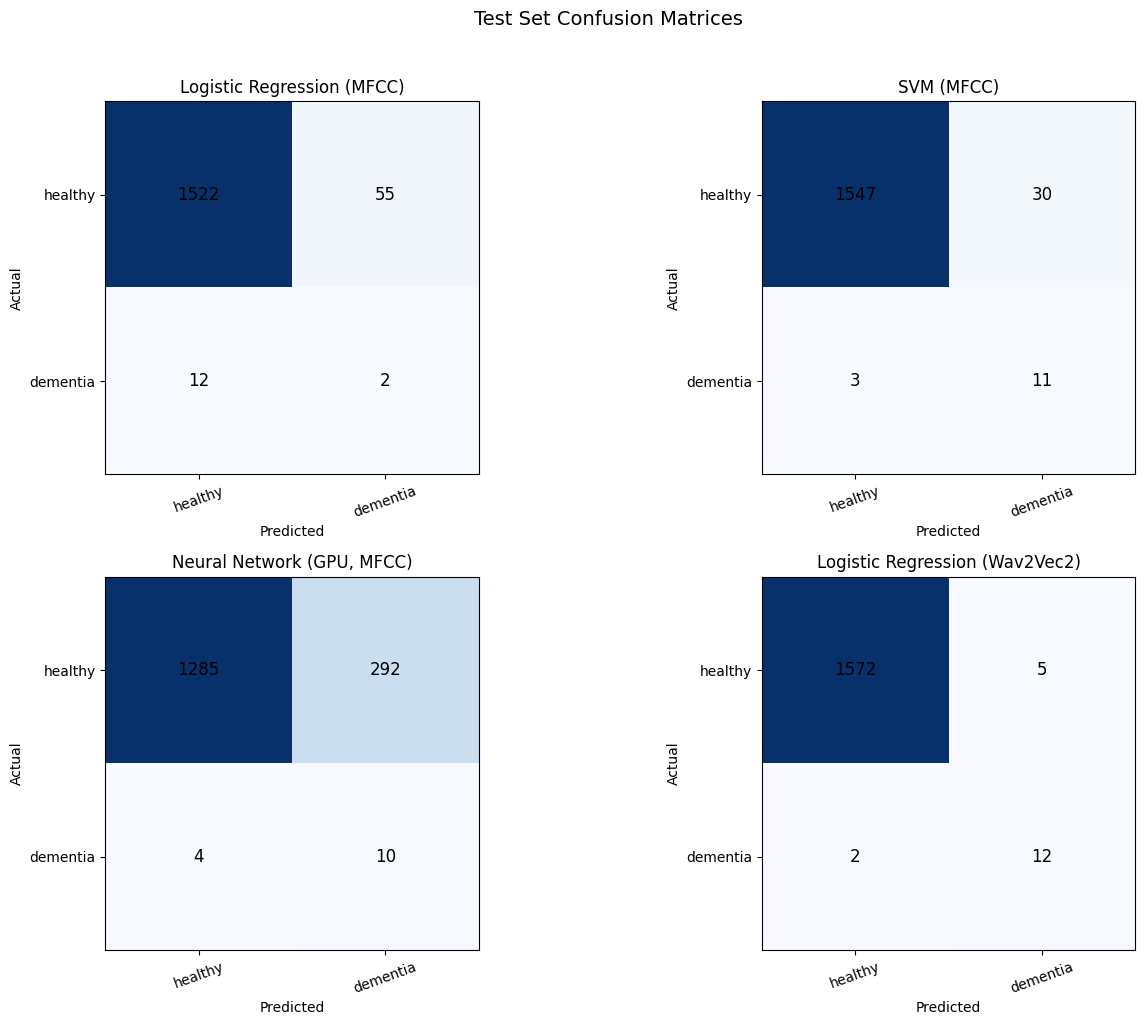

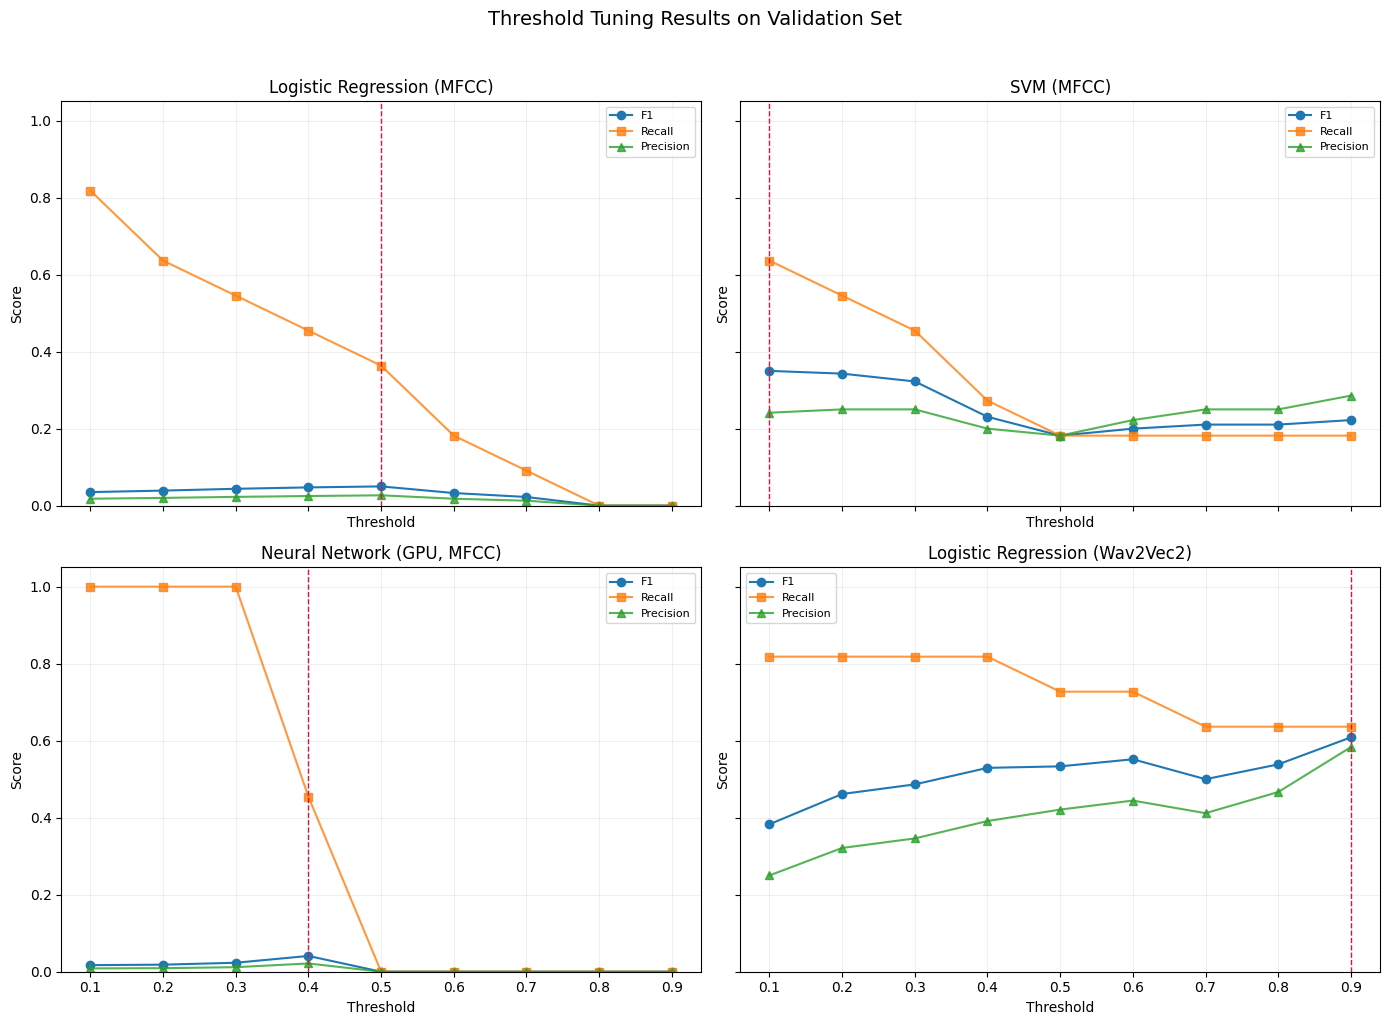

In [22]:
import matplotlib.pyplot as plt
from IPython.display import display

model_outputs = [
    ("Logistic Regression (MFCC)", lr_result, lr_threshold_df),
    ("SVM (MFCC)", svm_result, svm_threshold_df),
    ("Neural Network (GPU, MFCC)", nn_result, nn_threshold_df),
    ("Logistic Regression (Wav2Vec2)", w2v_result, w2v_threshold_df),
]

metrics_rows = []
threshold_rows = []

for model_name, result, threshold_df in model_outputs:
    cm = np.asarray(result["Confusion Matrix"])

    metrics_rows.append({
        "Model": model_name,
        "Threshold": result["Threshold"],
        "Accuracy": result["Accuracy"],
        "Precision": result["Precision"],
        "Recall": result["Recall"],
        "F1": result["F1"],
        "False Positives": result["False Positives"],
        "False Negatives": result["False Negatives"],
    })

    threshold_df = threshold_df.copy()
    threshold_df.insert(0, "Model", model_name)
    threshold_rows.append(threshold_df)

metrics_df = pd.DataFrame(metrics_rows)
threshold_results_df = pd.concat(threshold_rows, ignore_index=True)
best_threshold_summary_df = (
    threshold_results_df.sort_values(["Model", "F1", "Threshold"], ascending=[True, False, True])
    .groupby("Model", as_index=False)
    .first()
    [["Model", "Threshold", "Accuracy", "Precision", "Recall", "F1", "False Positives", "False Negatives"]]
)

print("Full Metrics Table")
display(metrics_df.round(4))

print("Best Threshold Summary")
display(best_threshold_summary_df.round(4))

print("Threshold Tuning Results")
display(threshold_results_df.round(4))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for axis, (model_name, result, _) in zip(axes.flat, model_outputs):
    cm = np.asarray(result["Confusion Matrix"])
    axis.imshow(cm, cmap="Blues")
    axis.set_title(model_name)
    axis.set_xlabel("Predicted")
    axis.set_ylabel("Actual")
    axis.set_xticks([0, 1])
    axis.set_yticks([0, 1])
    axis.set_xticklabels(["healthy", "dementia"], rotation=20)
    axis.set_yticklabels(["healthy", "dementia"])
    for row_index in range(cm.shape[0]):
        for col_index in range(cm.shape[1]):
            axis.text(col_index, row_index, int(cm[row_index, col_index]), ha="center", va="center", color="black", fontsize=12)

plt.suptitle("Test Set Confusion Matrices", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
for axis, (model_name, _, threshold_df) in zip(axes.flat, model_outputs):
    axis.plot(threshold_df["Threshold"], threshold_df["F1"], marker="o", label="F1")
    axis.plot(threshold_df["Threshold"], threshold_df["Recall"], marker="s", label="Recall", alpha=0.8)
    axis.plot(threshold_df["Threshold"], threshold_df["Precision"], marker="^", label="Precision", alpha=0.8)
    best_row = threshold_df.loc[threshold_df["F1"].idxmax()]
    axis.axvline(best_row["Threshold"], color="crimson", linestyle="--", linewidth=1)
    axis.set_title(model_name)
    axis.set_xlabel("Threshold")
    axis.set_ylabel("Score")
    axis.set_ylim(0, 1.05)
    axis.grid(True, alpha=0.2)
    axis.legend(fontsize=8)

plt.suptitle("Threshold Tuning Results on Validation Set", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()